# Importar Bibliotecas

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay, classification_report)

# Carregamento e exploração dos Dados

  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...

Distribuição das classes:
label
ham     4825
spam     747
Name: count, dtype: int64


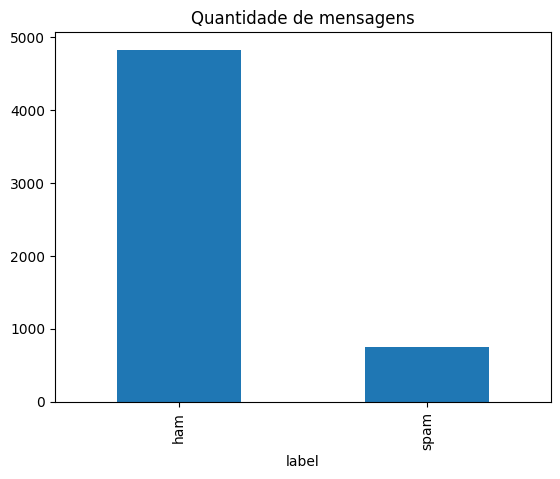

In [2]:
df = pd.read_csv("spam.csv", encoding="latin-1")

df = df[['v1', 'v2']]
df.columns = ['label', 'message']

print(df.head())
print("\nDistribuição das classes:")
print(df['label'].value_counts())

df['label'].value_counts().plot(kind='bar')
plt.title("Quantidade de mensagens")
plt.show()

# Pré-Processamento

In [3]:
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

X_train, X_test, y_train, y_test = train_test_split(df['message'], df['label'], test_size=0.3, random_state=42)

vectorizer = TfidfVectorizer()

X_train = vectorizer.fit_transform(X_train)
X_test = vectorizer.transform(X_test)

# Treinamento

In [6]:
modelo = LogisticRegression(max_iter=1000)
modelo.fit(X_train, y_train)

y_pred = modelo.predict(X_test)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)

print(f"Acurácia: {acc:.4f}")
print(f"Precisão: {prec:.4f}")
print(f"Recall: {rec:.4f}")

print("\nClassificação completa:")
print(classification_report(y_test, y_pred))

Acurácia: 0.9659
Precisão: 0.9939
Recall: 0.7443

Classificação completa:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98      1453
           1       0.99      0.74      0.85       219

    accuracy                           0.97      1672
   macro avg       0.98      0.87      0.92      1672
weighted avg       0.97      0.97      0.96      1672



# Matriz de Confusão

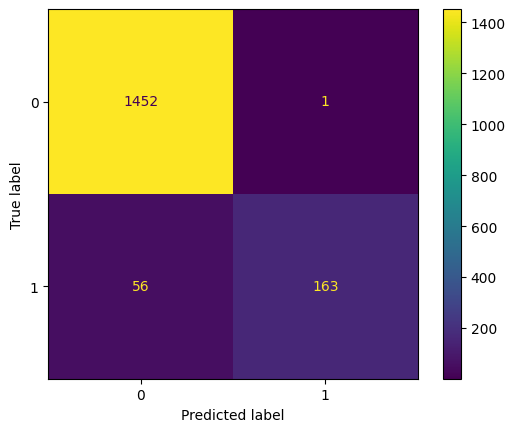

In [5]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.show()

# Novo Limite de Decisão

In [11]:
probs = modelo.predict_proba(X_test)[:, 1]

limite = 0.2

y_pred_limite = (probs >= limite).astype(int)

print("Limite:", limite)
print("Acurácia:", accuracy_score(y_test, y_pred_limite))
print("Precisão:", precision_score(y_test, y_pred_limite))
print("Recall:", recall_score(y_test, y_pred_limite))

Limite: 0.2
Acurácia: 0.9766746411483254
Precisão: 0.9017857142857143
Recall: 0.9223744292237442


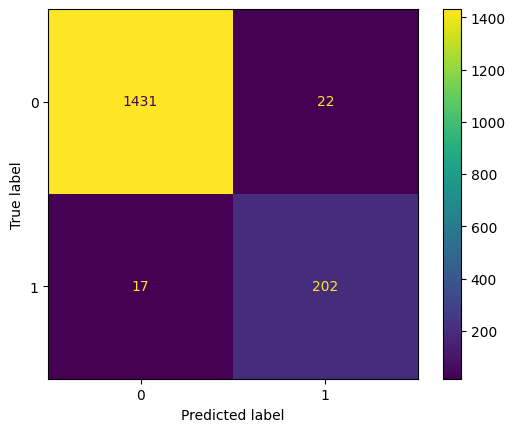

In [10]:
cm = confusion_matrix(y_test, y_pred_limite)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.show()

## Qual foi a acurácia, precisão e recall obtidos?

Inicialmente, utilizando o limite de decisão padrão da regressão logística (0,5), o modelo obteve:

- Acurácia: 96,59%
- Precisão: 99,39%
- Recall: 74,43%

Posteriormente, foi realizado um teste alterando o limite de decisão para 0,2. Nesse caso, as métricas foram:

- Acurácia: 97,67%
- Precisão: 90,18%
- Recall: 92,24%

A alteração do limite fez com que o modelo detectasse mais mensagens de spam, aumentando significativamente o recall. Além disso, a acurácia também aumentou de 96,59% para 97,67%, embora tenha ocorrido uma redução na precisão.


## O que cada métrica significa neste contexto (spam)?

Acurácia representa a porcentagem total de mensagens classificadas corretamente, considerando tanto mensagens legítimas quanto mensagens de spam.

Precisão indica, entre todas as mensagens classificadas como spam pelo modelo, quantas realmente eram spam. Uma alta precisão significa que poucas mensagens legítimas são classificadas incorretamente como spam.

Recall indica, entre todas as mensagens de spam existentes no conjunto de dados, quantas foram identificadas corretamente pelo modelo. Um alto recall significa que poucas mensagens de spam passam despercebidas.


## Para um filtro de spam, qual métrica você acha mais importante? Por quê?

Para um filtro de spam, considero o recall a métrica mais importante. O principal objetivo desse tipo de sistema é impedir que mensagens indesejadas cheguem à caixa de entrada do usuário. Então, é preferível detectar a maior quantidade possível de mensagens de spam, mesmo que isso ocasionalmente gere alguns falsos positivos.

Os resultados obtidos mostram claramente essa relação. Com o limite padrão de 0,5, a precisão foi muito alta (99,39%), mas o recall ficou em apenas 74,43%, permitindo que várias mensagens de spam passassem pelo filtro. Ao reduzir o limite para 0,2, o recall aumentou para 92,24%, indicando que a maior parte dos spams foi detectada. Embora a precisão tenha diminuído para 90,18%, ela ainda permaneceu em um valor elevado.

Além disso, a acurácia aumentou de 96,59% para 97,67%, mostrando que a alteração do limite melhorou o desempenho geral do modelo neste conjunto de dados.

Dessa forma, para um filtro de spam, a configuração com limite de decisão igual a 0,2 apresentou um desempenho mais adequado, pois conseguiu identificar uma quantidade muito maior de mensagens indesejadas sem comprometer excessivamente a precisão.
